# Task 1

## 1.1 Data Import and Cleaning

In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv("Region summary_ New South Wales STE 1.csv")

# remove rows without vital information
df = df.dropna(subset=['Measure Code', 'Parent Description', 'Description'])

# remove duplicates row
df = df.drop_duplicates()

# remove rows with missing values in year 2019 - 2024
df = df.dropna(subset=["2019", "2020", "2021", "2022", "2023", "2024"])

## 1.2 Indiviual Statics

In [11]:
# Identify, deduplicate and sort year columns
year_cols = sorted(list(set([col for col in df.columns if col.isdigit()])), key=int)

# filter the dataframe to keep only the rows we need
measure_code_map = {
    "total_resident_population": "ERP_P_20",
    "working_age_population_15_64": "ERP_18",
    "resident_male_population": "ERP_M_20",
    "resident_female_population": "ERP_F_20",
    "pop_0_4_total": "ERP_P_2",
    "pop_5_9_total": "ERP_P_3",
    "pop_10_14_total": "ERP_P_4",
    "pop_0_4_male": "ERP_M_2",
    "pop_5_9_male": "ERP_M_3",
    "pop_10_14_male": "ERP_M_4",
    "pop_0_4_female": "ERP_F_2",
    "pop_5_9_female": "ERP_F_3",
    "pop_10_14_female": "ERP_F_4",
    "pop_65_69": "ERP_P_15",
    "pop_70_74": "ERP_P_16",
    "pop_75_79": "ERP_P_17",
    "pop_80_84": "ERP_P_18",
    "pop_85_plus": "ERP_P_19",
}

df_base = df[df['Measure Code'].isin(measure_code_map.values())].copy()
df_base['metric_name'] = df_base['Measure Code'].map({v: k for k, v in measure_code_map.items()})
df_base = df_base.drop_duplicates(subset=['metric_name'])
df_base = df_base.set_index('metric_name')[year_cols].T.astype(float)

# Calculate aggregate population metrics
df_base['pop_0_14_total'] = df_base[['pop_0_4_total', 'pop_5_9_total', 'pop_10_14_total']].sum(axis=1)
df_base['pop_0_14_male_total'] = df_base[['pop_0_4_male', 'pop_5_9_male', 'pop_10_14_male']].sum(axis=1)
df_base['pop_0_14_female_total'] = df_base[['pop_0_4_female', 'pop_5_9_female', 'pop_10_14_female']].sum(axis=1)
df_base['pop_65_plus_total'] = df_base[['pop_65_69', 'pop_70_74', 'pop_75_79', 'pop_80_84', 'pop_85_plus']].sum(axis=1)

# Calculate 5 core indicators
result = pd.DataFrame(index=df_base.index)
result.index.name = 'year'

# 1. Child sex ratio (0-14 years male / 0-14 years female)
result['child_sex_ratio(male/female)'] = np.where(
    df_base['pop_0_14_female_total'] == 0,
    np.nan,
    df_base['pop_0_14_male_total'] / df_base['pop_0_14_female_total']
).round(4)

# 2. Total population sex ratio (total male / total female)
result['total_sex_ratio(male/female)'] = np.where(
    df_base['resident_female_population'] == 0,
    np.nan,
    df_base['resident_male_population'] / df_base['resident_female_population']
).round(4)

# 3. Child dependency ratio (0-14 population / 15-64 working age population * 100%)
result['child_dependency_ratio(%)'] = np.where(
    df_base['working_age_population_15_64'] == 0,
    np.nan,
    (df_base['pop_0_14_total'] / df_base['working_age_population_15_64']) * 100
).round(2)

# 4. Old age dependency ratio (65+ population / 15-64 working age population * 100%)
result['old_age_dependency_ratio(%)'] = np.where(
    df_base['working_age_population_15_64'] == 0,
    np.nan,
    (df_base['pop_65_plus_total'] / df_base['working_age_population_15_64']) * 100
).round(2)

# 5. Population aging index (elderly population share / child population share)
df_base['elderly_population_share'] = np.where(df_base['total_resident_population'] == 0, np.nan, df_base['pop_65_plus_total'] / df_base['total_resident_population'])
df_base['child_population_share'] = np.where(df_base['total_resident_population'] == 0, np.nan, df_base['pop_0_14_total'] / df_base['total_resident_population'])
result['population_aging_index'] = np.where(
    df_base['child_population_share'] == 0,
    np.nan,
    df_base['elderly_population_share'] / df_base['child_population_share']
).round(4)

# remove rows with all NaN/0 values
result_clean = result.dropna(how='all').replace(0, np.nan).dropna(how='all')
result_clean = result_clean.sort_index()

# Output
print(result_clean.to_string())

      child_sex_ratio(male/female)  total_sex_ratio(male/female)  child_dependency_ratio(%)  old_age_dependency_ratio(%)  population_aging_index
year                                                                                                                                            
2019                        1.0600                        0.9882                      28.46                        25.08                  0.8812
2020                        1.0607                        0.9879                      28.46                        25.86                  0.9087
2021                        1.0619                        0.9886                      28.67                        26.75                  0.9330
2022                        1.0609                        0.9885                      28.49                        27.15                  0.9529
2023                        1.0616                        0.9897                      27.72                        27.09          

## 1.3 key findings

1. Accelerated Population Aging ：
The population aging index rose steadily from 0.8812 in 2019 to 1.0074 in 2024, meaning the share of the elderly population has overtaken that of the child population. Meanwhile, the old-age dependency ratio increased from 25.08% to 27.32%, indicating growing pressure on the working-age population regarding elderly care over the period.

2. Persistent Gender Imbalance Among Children：
The child dependency ratio declined slightly from 28.46% to 27.12%. This reflects a reduction in the share of the child population and decreased pressure on child-rearing, signaling a low-fertility trend. Meanwhile, the child sex ratio remained persistently high at around 1.06—significantly above the total population sex ratio—showing a consistent male bias among children that may affect future marriage markets.

3. Overall Balanced Gender Structure：
The total sex ratio stayed stable between 0.9879 and 0.9898, with females slightly outnumbering males, indicating an overall balanced gender structure. A slow upward trend in this ratio from 2019 to 2024 suggests a gradual increase in the male population share, which might be driven by the gender imbalance among children.

4. Shift in Major Dependency Pressure from Child-Rearing to Elderly Care：
In 2019, the child dependency ratio (28.46%) was higher than the old-age dependency ratio (25.08%), meaning the primary pressure stemmed from child-rearing. By 2024, the two ratios had nearly converged (27.12% vs. 27.32%), signaling a structural shift in the population.

# Task 2

## 2.1 Shape file import

In [12]:
import pandas as pd
import numpy as np
import geopandas as gpd
import requests
import json
import os
from sqlalchemy import create_engine, text
import psycopg2
import geoalchemy2

sa4_gdf = gpd.read_file("SA4_2021_AUST_SHP_GDA2020/SA4_2021_AUST_GDA2020.shp")

sa2_gdf = gpd.read_file("SA2_2021_AUST_SHP_GDA2020/SA2_2021_AUST_GDA2020.shp")

selected_sa4 = sa4_gdf[sa4_gdf["SA4_NAME21"] == "Sydney - City and Inner South"] # "Sydney - City and Inner South" "Sydney - South West"

sa2_in_selected_sa4 = sa2_gdf[sa2_gdf.within(selected_sa4.geometry.iloc[0])]

#selected_greater_sydney = sa2_gdf[sa2_gdf["GCC_NAME21"] == "Greater Sydney"]

#print(selected_greater_sydney["SA4_NAME21"].unique())

#print(sa2_in_selected_sa4)

## 2.2 Search POIs
Iterate through all SA2s under selected SA4 to get all POIs to build a dataframe contains all attributes and geometry informations

In [13]:
def nearbyPOI(xmin, ymin, xmax, ymax):
    base_url = "https://maps.six.nsw.gov.au/arcgis/rest/services/public/NSW_POI/MapServer/0/query"
    params = {
        "geometry": f'{{"xmin":{xmin},"ymin":{ymin},"xmax":{xmax},"ymax":{ymax},"spatialReference":{{"wkid":4326}}}}',
        "outFields": "*",
        "returnGeometry": "true",
        "f": "json"
    }
    r = requests.get(base_url, params=params)
    return r.json().get("features", [])

all_poi = []

sa2_wgs84 = sa2_in_selected_sa4.to_crs("EPSG:4326")

for idx, row in sa2_wgs84.iterrows():
    sa2_code = row["SA2_CODE21"]
    sa2_name = row["SA2_NAME21"]
    bounds = row.geometry.bounds
    xmin, ymin, xmax, ymax = bounds
    sa2_geom = row.geometry

    pois = nearbyPOI(xmin, ymin, xmax, ymax)
    poi_list = []
    for p in pois:
            lon = p["geometry"]["x"]
            lat = p["geometry"]["y"]
            point = gpd.points_from_xy([lon], [lat])[0]

            if sa2_geom.covers(point):
                p["attributes"]["SA2_CODE21"] = sa2_code
                p["attributes"]["SA2_NAME21"] = sa2_name
                poi_list.append(p)
    all_poi.extend(poi_list)

poi_list = []

for p in all_poi:
    row = {**p["attributes"], **p["geometry"]}
    poi_list.append(row)

poi_df = pd.DataFrame(poi_list)
#print(poi_df)

## 2.3 database operation
Connect to postgres with postGis extension and insert/read GeoDataFrame with database using python

In [14]:
if not os.path.exists("Credentials.json"):
    config_data = {
        "host": "localhost",
        "user": "postgres",
        "password": "password", # your own password
        "port": 5432
    }

    with open("Credentials.json", "w", encoding="utf-8") as f:
        json.dump(config_data, f, indent=4)
        

In [15]:
credentials = "Credentials.json"

def pgconnect(credential_filepath, db_schema="public"):
    with open(credential_filepath, 'r') as f:
        db_conn_dict = json.load(f)
        host       = db_conn_dict['host']
        db_user    = db_conn_dict['user']
        db_pw      = db_conn_dict['password']
        default_db = db_conn_dict['user']
        port       = db_conn_dict['port']
        try:
            db = create_engine(f'postgresql+psycopg2://{db_user}:{db_pw}@{host}:{port}/{default_db}', echo=False)
            conn = db.connect()
            print('Connected successfully.')
        except Exception as e:
            print("Unable to connect to the database.")
            print(e)
            db, conn = None, None
        return db, conn
    
def query(conn, sqlcmd, args=None, df=True):
    result = pd.DataFrame() if df else None
    try:
        if df:
            result = pd.read_sql_query(sqlcmd, conn, params=args)
        else:
            result = conn.execute(text(sqlcmd), args).fetchall()
            result = result[0] if len(result) == 1 else result
    except Exception as e:
        print("Error encountered: ", e, sep='\n')
    return result

db, conn = pgconnect(credentials)

with conn.begin():
    conn.execute(text("CREATE EXTENSION IF NOT EXISTS postgis;"))
    conn.execute(text("CREATE SCHEMA IF NOT EXISTS pois;"))
    conn.execute(text("DROP TABLE IF EXISTS pois.poi;")) 

poi_gdf = gpd.GeoDataFrame(poi_df, geometry= gpd.points_from_xy(poi_df['x'], poi_df['y']), crs="EPSG:4326")

#print(poi_gdf)

poi_gdf.to_postgis("poi", conn, schema="pois", if_exists="replace")

display(query(conn, "SELECT * FROM pois.poi LIMIT 10;"))

conn.close()

db.dispose()


Connected successfully.


,objectid,topoid,poigroup,poitype,poiname,poilabel,poilabeltype,poialtlabel,poisourcefeatureoid,accesscontrol,...,centroidid,shapeuuid,changetype,processstate,urbanity,SA2_CODE21,SA2_NAME21,x,y,geometry
0,53133,511751622,8,Suburb,BANKSMEADOW,BANKSMEADOW,NAMED,NaN,131,1,...,None,bd3bd8d4-6399-3514-9b38-024e15003fff,I,None,S,117011320,Banksmeadow,151.214736,-33.961926,0101000020E6100000FB9E421DDFE66240DF58B26220FB...
1,97795,514234550,8,Urban Place,EAST BOTANY,EAST BOTANY,NAMED,NaN,164,1,...,None,4afd6d38-6acc-35a1-b4e9-9239458325c7,M,None,U,117011320,Banksmeadow,151.215473,-33.946782,0101000020E610000098384A28E5E662403760CE2430F9...
2,128047,517407771,4,Wharf,NaN,Wharf,GENERIC,NaN,73,1,...,None,3dca6fa2-84cd-3be0-aaeb-c55758350860,I,None,S,117011320,Banksmeadow,151.220483,-33.968008,0101000020E61000007B63E6320EE762401DBF17AFE7FB...
3,128049,517407773,4,Wharf,NaN,Wharf,GENERIC,NaN,73,1,...,None,509d8eaf-b568-394d-a660-100464ed1e89,I,None,S,117011320,Banksmeadow,151.220343,-33.967707,0101000020E6100000DCAFC40D0DE7624091FDDCD2DDFB...
4,2999,500321774,1,Place Of Worship,ST MATTHEW'S ANGLICAN CHURCH,ST MATTHEW'S ANGLICAN CHURCH,NAMED,ANGLICAN,19,1,...,None,65c5e7a5-a283-325a-970f-8dca72291b2d,M,None,U,117011321,Botany,151.195602,-33.941055,0101000020E61000002ED1845F42E6624060EBD58074F8...
5,3001,500321819,3,Park,BOORALEE PARK,BOORALEE PARK,NAMED,NaN,61,1,...,None,175372cb-0ee9-38bf-8c12-92c8da9ea3c3,I,None,U,117011321,Botany,151.200948,-33.941418,0101000020E61000008CACF32A6EE66240BDD5CE6180F8...
6,3002,500321841,1,Post Office,BOTANY POST OFFICE,BOTANY POST OFFICE,NAMED,NaN,21,1,...,None,cc296f4c-eb35-39ea-9e6d-35d2472b3219,I,None,U,117011321,Botany,151.197007,-33.944413,0101000020E6100000FBEB58E24DE662401D43BC83E2F8...
7,3003,500321885,3,Park,SIR JOSEPH BANKS PARK,SIR JOSEPH BANKS PARK,NAMED,NaN,61,1,...,None,f76ead29-484d-3ad5-9b04-e8050da8e0e0,I,None,S,117011321,Botany,151.192360,-33.950407,0101000020E61000004BBB08D127E662400881E3ECA6F9...
8,3008,500321974,3,Park,GARNET JACKSON RESERVE,GARNET JACKSON RESERVE,NAMED,NaN,61,1,...,None,5b51223f-a199-3a7b-b299-a5e8dd013bd7,I,None,U,117011321,Botany,151.208587,-33.946997,0101000020E6100000B22B9ABDACE662402042F33437F9...
9,3009,500321996,3,Golf Course,BOTANY MUNICIPAL GOLF LINKS,BOTANY MUNICIPAL GOLF LINKS,NAMED,NaN,54,1,...,None,2095f2c4-96fe-33af-bc68-5fa16794343f,I,None,S,117011321,Botany,151.209774,-33.960649,0101000020E6100000ECC81678B6E662408BC66B88F6FA...


# Task 3

## 3.1 basic Z-score and Sigmoid

In [16]:
import pandas as pd
import numpy as np

poi_count = poi_df.groupby("SA2_NAME21").size().reset_index()
poi_count.columns = ["sa2_name", "poi_num"]

mean_poi = poi_count["poi_num"].mean()
std_poi = poi_count["poi_num"].std(ddof=0)
poi_count["z_poi"] = (poi_count["poi_num"] - mean_poi) / std_poi


poi_count["score"] = 1 / (1 + np.exp(-poi_count["z_poi"]))

poi_count = poi_count.sort_values(by="score", ascending=False)
print(poi_count)


                             sa2_name  poi_num     z_poi     score
20       Sydenham - Tempe - St Peters      354  3.634410  0.974279
21     Sydney (North) - Millers Point      315  3.145457  0.958729
11                      Newtown (NSW)       92  0.349650  0.586533
15        Potts Point - Woolloomooloo       73  0.111442  0.527832
12  Pagewood - Hillsdale - Daceyville       68  0.048756  0.512187
13               Petersham - Stanmore       64 -0.001393  0.499652
2             Camperdown - Darlington       61 -0.039005  0.490250
19                        Surry Hills       61 -0.039005  0.490250
6           Erskineville - Alexandria       59 -0.064079  0.483986
7                Glebe - Forest Lodge       59 -0.064079  0.483986
22         Sydney (South) - Haymarket       57 -0.089154  0.477726
9                Marrickville - South       56 -0.101691  0.474599
4                        Darlinghurst       49 -0.189452  0.452778
8                Marrickville - North       47 -0.214526  0.44

# Task 4

## 4.1 visualisation of score

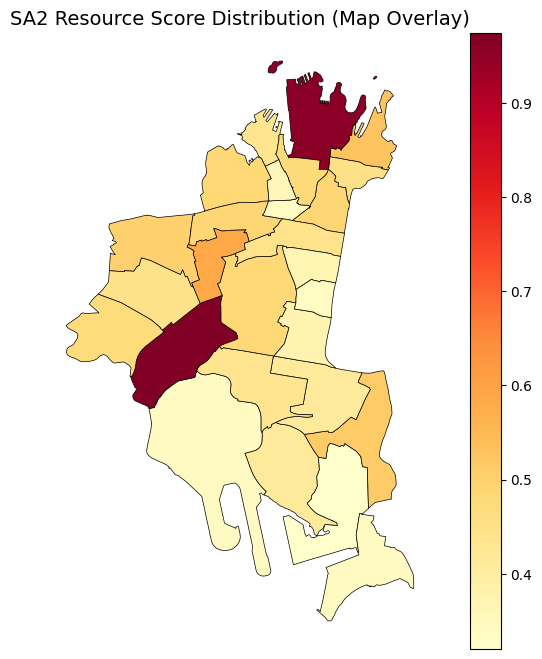

In [17]:
import matplotlib.pyplot as plt

sa2s = sa2_in_selected_sa4.merge(
    poi_count,
    left_on="SA2_NAME21",
    right_on="sa2_name",
    how="left"
)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

sa2s.plot(
    column="score",
    cmap="YlOrRd",
    linewidth=0.5,
    ax=ax,
    edgecolor="black",
    legend=True
)

ax.set_title("SA2 Resource Score Distribution (Map Overlay)", fontsize=14)
ax.axis("off")
plt.show()
